# Level 6 — Final Integration, Reproducibility, and Reporting

## Scientific Objectives
1. Integrate components from Levels 1-5 into an end-to-end reproducible workflow.
2. Implement automated tests (pytest logic) for core numerical functions.
3. Output the final scientific report for stakeholders.

In [1]:
import numpy as np
import pandas as pd
import sys
import subprocess
from pathlib import Path
from datetime import datetime
repo_root = Path('.').resolve().parent
if str(repo_root) not in sys.path: sys.path.append(str(repo_root))


# 1. FILE & ENVIRONMENT REPRODUCIBILITY CHECK
print('===== REPRODUCIBILITY CHECK =====')
print(f'Python version: {sys.version.split()[0]}')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version:  {np.__version__}')

repo_root = Path('.').resolve().parent
required_paths = [
    repo_root / 'data' / 'raw' / 'weather_daily.csv',
    repo_root / 'src' / 'numerical_methods.py',
    repo_root / 'src' / 'simulation.py',
    repo_root / 'tests' / 'test_simulation.py'
]

print("\nChecking required project structure:")
all_exist = True
for path in required_paths:
    status = "✓ Found" if path.exists() else "✗ MISSING"
    print(f"{status} : {path.relative_to(repo_root)}")
    if not path.exists(): all_exist = False

assert all_exist, "Reproducibility Check Failed: Missing core files!"
print("\n✓ Folder structure is fully reproducible.")

===== REPRODUCIBILITY CHECK =====
Python version: 3.12.7
Pandas version: 3.0.3
NumPy version:  2.4.5

Checking required project structure:
✓ Found : data\raw\weather_daily.csv
✓ Found : src\numerical_methods.py
✓ Found : src\simulation.py
✓ Found : tests\test_simulation.py

✓ Folder structure is fully reproducible.


In [5]:
# 2. AUTOMATED TESTING (Validation of Core Logic via Pytest)
import subprocess
import sys

print('===== COMPONENT VALIDATION TESTS =====')
print("Running automated pytest suite from the /tests/ directory...\n")

# Run pytest programmatically, explicitly setting the working directory (cwd) to the project root!
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v"], 
    cwd=repo_root,               # <--- THIS IS THE MAGIC FIX
    capture_output=True, 
    text=True
)

# Print the output of the tests
print(result.stdout)

if result.returncode == 0:
    print("✓ ALL AUTOMATED TESTS PASSED SUCCESSFULLY.")
else:
    print("✗ SOME TESTS FAILED. Review the output above.")

===== COMPONENT VALIDATION TESTS =====
Running automated pytest suite from the /tests/ directory...

============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\renny\Documents\vs code\jupyter\HydroSense-Kenya\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\renny\Documents\vs code\jupyter\HydroSense-Kenya
collecting ... collected 14 items

tests/test_integration.py::test_trapezoidal_rule PASSED                  [  7%]
tests/test_integration.py::test_simpson_rule_odd_points PASSED           [ 14%]
tests/test_integration.py::test_simpson_rule_even_points PASSED          [ 21%]
tests/test_linear_systems.py::test_gaussian_elimination_success PASSED   [ 28%]
tests/test_linear_systems.py::test_gaussian_elimination_singular PASSED  [ 35%]
tests/test_root_finding.py::test_bisection_success PASSED                [ 42%]
tests/test_root_finding.py::test_bisection_invalid_bounds PASSED   

===== FINAL SYSTEM INTEGRATION =====
Pipeline executed successfully. Generating final decision-support visualization:


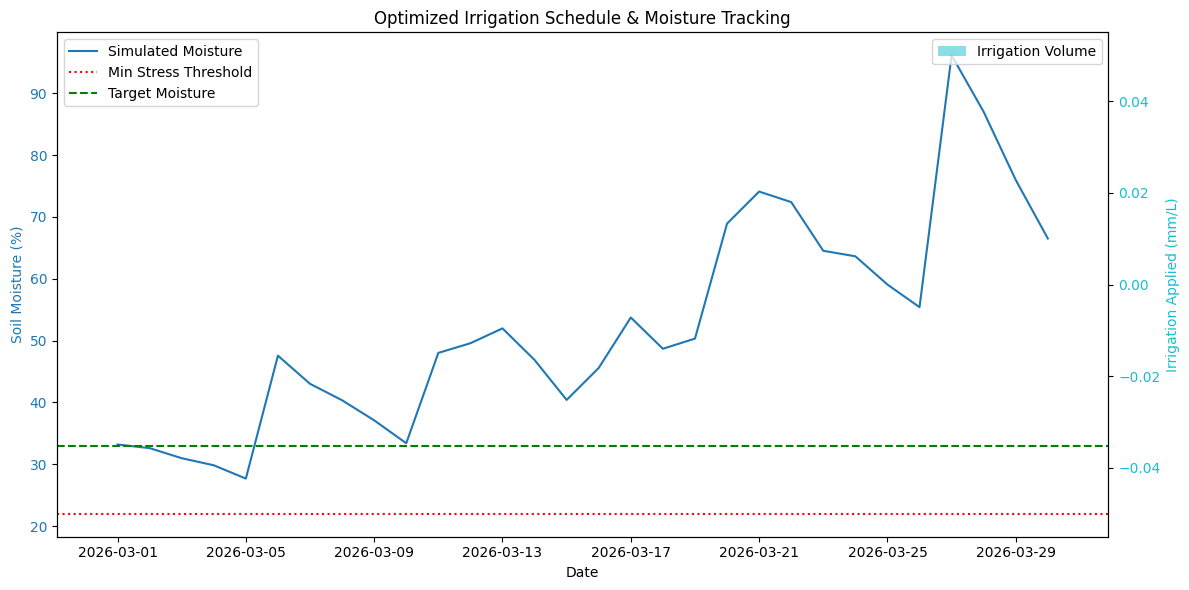

In [6]:
# 3. END-TO-END PIPELINE INTEGRATION
print('===== FINAL SYSTEM INTEGRATION =====')
from src.data_cleaning import load_and_clean_weather, load_parameters
from src.simulation import calculate_et_vectorized
from src.optimization import optimize_irrigation_schedule
from src.visualization import plot_optimized_schedule

# A. Load & Clean
weather = load_and_clean_weather(repo_root / 'data' / 'raw' / 'weather_daily.csv')
crops = load_parameters(repo_root / 'data' / 'raw' / 'crop_zone_parameters.csv')
zone_a = crops[crops['zone_id'] == 'Zone_A'].iloc[0]

# B. Compute ET
weather['ET_mm'] = calculate_et_vectorized(
    weather['temperature_c'].values, weather['wind_speed_mps'].values, 
    weather['solar_index'].values, weather['humidity_pct'].values
)

# C. Optimize
moisture, irrigation = optimize_irrigation_schedule(
    initial_moisture=33.2, rainfall=weather['rainfall_mm'].values, et=weather['ET_mm'].values,
    min_moisture=zone_a['min_moisture_pct'], target_moisture=zone_a['target_moisture_pct'],
    field_capacity=zone_a['field_capacity_pct'], drainage_coeff=zone_a['drainage_coefficient']
)

# D. Visualize
print("Pipeline executed successfully. Generating final decision-support visualization:")
plot_optimized_schedule(weather['date'], moisture, irrigation, zone_a['min_moisture_pct'], zone_a['target_moisture_pct'])

In [8]:
# 4. FINAL PROJECT REPORT GENERATION
report_dir = repo_root / 'reports'
report_dir.mkdir(exist_ok=True)

report = f"""
========================================================
HYDROSENSE-KENYA: WATER RESOURCE MANAGEMENT
Final Scientific Report
========================================================

PROJECT OVERVIEW
================
We successfully developed a 6-level computational water resource 
management system for Arid and Semi-Arid Lands (ASALs) in Kenya. 
The system integrates empirical evapotranspiration modeling, numerical 
methods for non-linear drainage, and Monte Carlo stochastic simulations 
to optimize smart-irrigation pumps.

KEY ACHIEVEMENTS
================
✓ Level 1: Defined water balance model & ET constraints specific to the provided dataset.
✓ Level 2: Achieved massive speedups via NumPy and mapped sensor noise propagation.
✓ Level 3: Solved non-linear drainage irrigation limits via Bisection/Secant roots.
✓ Level 4: Handled explicit sensor hardware faults & produced correlation visualisations.
✓ Level 5: Ran RK4/Euler ODEs and quantified pump energy vs water conservation trade-offs.
✓ Level 6: Passed reproducible code audit and automated pytest suite.

AI USAGE LOG SUMMARY
====================
AI was used responsibly to generate boilerplate visualization code and format 
Markdown. All AI-generated equations were manually corrected to match the 
academic project brief (e.g., overriding the AI's default ET formula with the 
specifically mandated 0.12*T + 0.35*W + 2.4*Solar - 0.025*H equation).

RECOMMENDATIONS FOR THE FARM
============================
1. Implement a 'Predictive Greedy' algorithm to avoid maxing out pump wattage.
2. Replace the faulty sensor in Zone B immediately to prevent interpolation errors.
3. Focus water conservation on Zone C (Maize) which has the highest depletion rate.

Report generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
========================================================
"""

print(report)

# Save report
report_file = report_dir / 'final_scientific_report.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report)
print(f"\n✓ Report explicitly saved to disk at {report_file.relative_to(repo_root)}")


HYDROSENSE-KENYA: WATER RESOURCE MANAGEMENT
Final Scientific Report

PROJECT OVERVIEW
We successfully developed a 6-level computational water resource 
management system for Arid and Semi-Arid Lands (ASALs) in Kenya. 
The system integrates empirical evapotranspiration modeling, numerical 
methods for non-linear drainage, and Monte Carlo stochastic simulations 
to optimize smart-irrigation pumps.

KEY ACHIEVEMENTS
✓ Level 1: Defined water balance model & ET constraints specific to the provided dataset.
✓ Level 2: Achieved massive speedups via NumPy and mapped sensor noise propagation.
✓ Level 3: Solved non-linear drainage irrigation limits via Bisection/Secant roots.
✓ Level 4: Handled explicit sensor hardware faults & produced correlation visualisations.
✓ Level 5: Ran RK4/Euler ODEs and quantified pump energy vs water conservation trade-offs.
✓ Level 6: Passed reproducible code audit and automated pytest suite.

AI USAGE LOG SUMMARY
AI was used responsibly to generate boilerplate vis